# Fitting Example (NLSF & MLE) in CPU and GPU - Bi-exponential FLI data processing

A simulated, full 3-D fluorescence lifetime image dataset of a two-well plate (in silico) is generated (using the same simulator as the "Whole Image Simulation" example). Each well is assigned a different set of lifetime / FRET parameters. The data is then fitted pixel by pixel with two estimators, each on the CPU and on the GPU, and processed with the phasor method:

- **Non-linear least squares (NLSF)**: minimizes the weighted sum of squared residuals between the IRF-convolved model and the decay.
- **Maximum likelihood estimation (MLE)**: maximizes the Poisson log-likelihood of the photon counts directly.

This example walks through:
- Simulating the two-well FLI data and inspecting the ground-truth parameters
- Fitting the whole image with NLSF and with MLE on the CPU
- Fitting the same image with NLSF and with MLE on the GPU
- Comparing the CPU and GPU parameter maps, their distributions, accuracy and fit quality with the ground truth
- Comparing CPU and GPU estimates pixel by pixel, and the four fits at a single pixel
- The phasor computation, with pixel-wise IRF calibration to benchmark the results.
- Phasor plot and pixel-wise phasor color overlays

<small>Author - Vikas</small>

In [1]:
## importing the modules required for this work
import sys

import numpy as np

sys.path.insert(0, "ex_helper")  # local helper for synthetic image generation

from sim_general_image import ROIMaskGenerator

from pyfli.analysis.utils import random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.io import DataOperations
from pyfli.phasor.phasorS import PhasorAnalyzer
from pyfli.simulator import FLIModelImageGenerator

## Loading the IRF

In [2]:
# Path to the local IRF file
IRF_PATH = "<select file/folder path>"

In [3]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


## Simulation configuration

`MODEL_TYPE` selects the decay model for both the simulation and the fits. `get_config` builds a per-well configuration by overriding `BASE_CONFIG`.

In [4]:
# select the type of decay model to simulate
MODEL_TYPE = "bi-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4  # fraction of mono-exponential model in sampled data

# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "tau2_beta_range": (2.5, 0.1),
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": mono_fraction,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

In [5]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


In [6]:
# Shared plotting / phasor configuration used by the two-well example below
colorset = "rainbow"
freq_hz = freq[1] * 1e6
jet_m_well = ColorProcessor().lowest_zero("jet")
bg_color = "black"  # either "black" or "white"
ph_cols_ = "viridis_r"


## Two wells example

A two-well plate is simulated, with each well assigned a different set of ground-truth lifetime / FRET parameters.

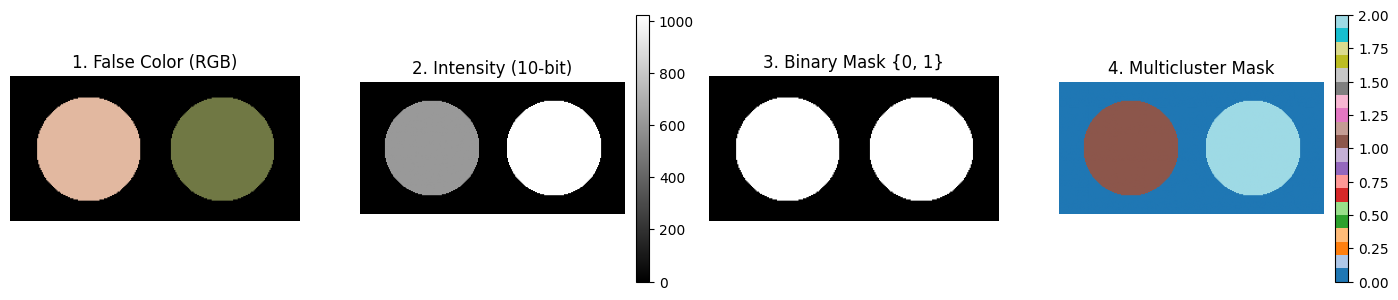

In [7]:
from sim_general_image import WellPlateShape

h_well, w_well = 128, 256
generator_well = ROIMaskGenerator((h_well, w_well), top=10, bottom=10, left=10, right=10)
TwoWells = WellPlateShape(rows=1, cols=2, gap=0.15)

custom_intensities_well = [ 0.6, 1.0]
_ = generator_well.plot_preview(
    TwoWells,
    bit_depth=10,
    intensities=custom_intensities_well,
    show=True,
)

In [8]:
ROI0_well = {}
ROI1_well = get_config(
    tau2_beta_range=(0.1, 1.8),
    efficiency = (5, 2),  
    A1_fraction = (7, 13),
)
ROI2_well = get_config(
    tau2_beta_range=(0.2, 0.8),
    efficiency = (10, 10),  
    A1_fraction = (15, 10),
)

In [9]:
img_intensity_well = generator_well.generate_intensity_image(
    TwoWells, intensities=custom_intensities_well
)
img_cluster_well = generator_well.generate_cluster_mask(TwoWells)
b_bool_mask_well = generator_well.generate_binary_mask(TwoWells)

simulated_img_well = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity_well,
    roi_mask=img_cluster_well,
    roi_params=[ROI0_well, ROI1_well, ROI2_well],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask_well,
)

gt_data_well = simulated_img_well.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x256x256]...


Check the decay, IRF, and fit at a randomly selected pixel.

the non-zero pixel selected for probing is (35, 103)


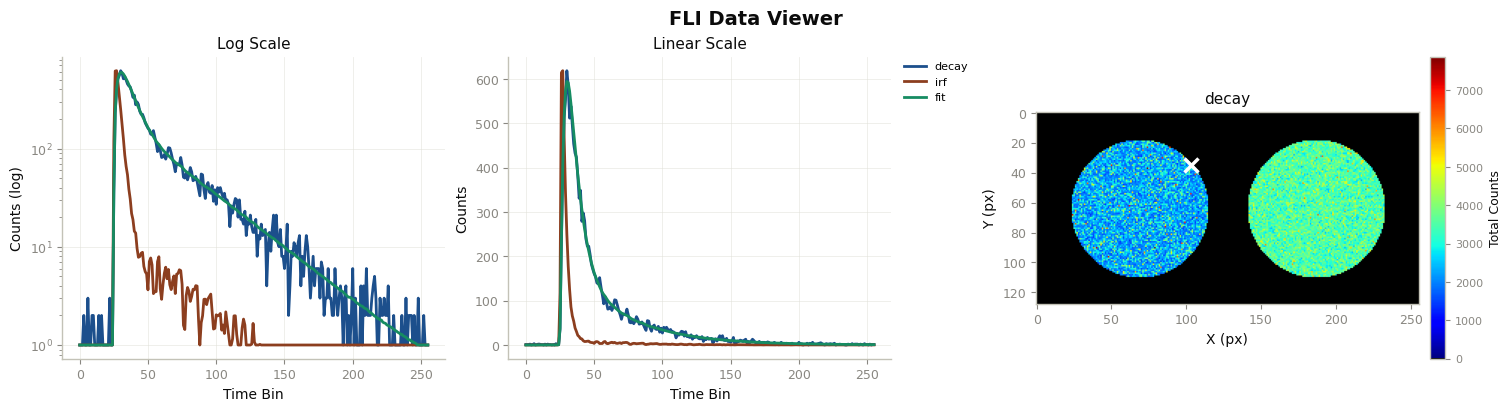

INFO:pyfli:
  Pixel (35, 103)
  ─────────────────────
  A         14165.6523
  α         0.5340
  τ₁        0.3890
  τ₂        1.8303
  R²        —
  Red.χ²    —
  Raw.χ²    —
  Pearson   —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [10]:
_decay_well = gt_data_well["raw_data"]["decay"]
_irf_well = gt_data_well["raw_data"]["irf"]
x_well, y_well = random_true_pixel(b_bool_mask_well)
TRs_well = gt_data_well["results"]["TR_maps"]
maps_well = gt_data_well["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x_well}, {y_well})")
irf_norm_well = Normalization(_irf_well).norm_scale(_decay_well)
DataViewer().plot_fli_px(
    data_list=[_decay_well, irf_norm_well, TRs_well["fit_map"], TRs_well["residual_map"]],
    pixel=(x_well, y_well),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m_well,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps_well, px=(x_well, y_well))

Distribution of the simulated ground-truth parameters across the image, before computing phasors.

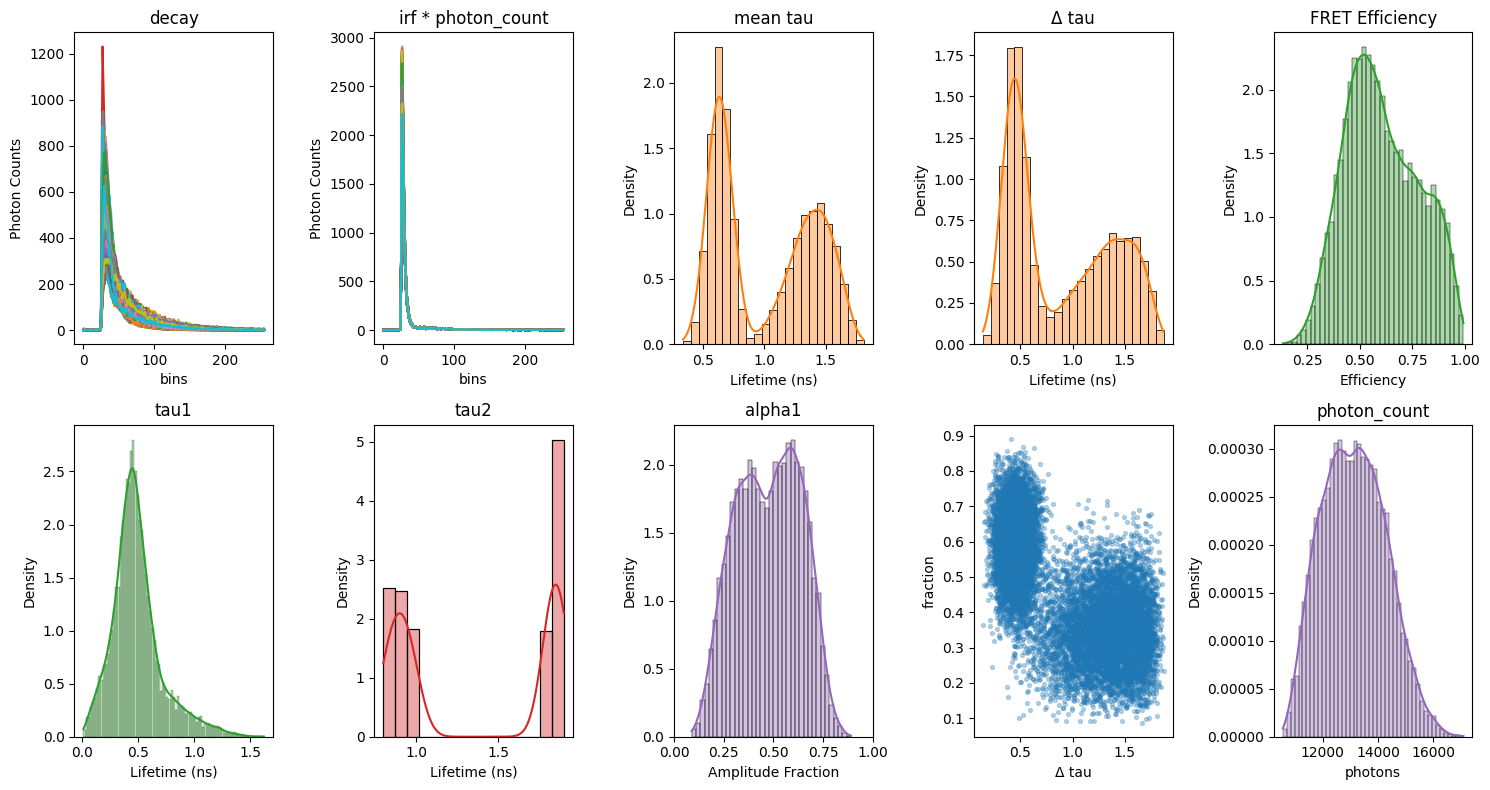

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

res_well = gt_data_well["results"]["maps"]

b_bool_mask_well_bool = b_bool_mask_well.astype(bool)
valid_px_well = np.argwhere(b_bool_mask_well)
rng_well = np.random.default_rng(0)
sample_idx_well = rng_well.choice(len(valid_px_well), size=min(300, len(valid_px_well)), replace=False)
sample_px_well = valid_px_well[sample_idx_well]
decay_sample_well = _decay_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
irf_sample_well = _irf_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
photon_count_sample_well = res_well["photon_count_map"][sample_px_well[:, 0], sample_px_well[:, 1]]

tau1_valid_well = res_well["tau1_map"][b_bool_mask_well_bool]
tau2_valid_well = res_well["tau2_map"][b_bool_mask_well_bool]
alpha1_valid_well = res_well["alpha1_map"][b_bool_mask_well_bool]
tau_mean_valid_well = res_well["tau_mean_map"][b_bool_mask_well_bool]
efficiency_valid_well = res_well["fret_efficiency_map"][b_bool_mask_well_bool]
photon_count_valid_well = res_well["photon_count_map"][b_bool_mask_well_bool]
tau_dif_well = tau2_valid_well - tau1_valid_well

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

axes[0, 0].plot(decay_sample_well.T)
axes[0, 0].set_title("decay")
axes[0, 0].set_xlabel("bins")
axes[0, 0].set_ylabel("Photon Counts")

axes[0, 1].plot((irf_sample_well * photon_count_sample_well[:, None]).T)
axes[0, 1].set_title("irf * photon_count")
axes[0, 1].set_xlabel("bins")
axes[0, 1].set_ylabel("Photon Counts")

sns.histplot(data=tau_mean_valid_well, ax=axes[0, 2], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 2].set_title("mean tau")
axes[0, 2].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau_dif_well, ax=axes[0, 3], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 3].set_title("Δ tau")
axes[0, 3].set_xlabel("Lifetime (ns)")

sns.histplot(data=efficiency_valid_well, ax=axes[0, 4], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[0, 4].set_title("FRET Efficiency")
axes[0, 4].set_xlabel("Efficiency")

sns.histplot(data=tau1_valid_well, ax=axes[1, 0], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[1, 0].set_title("tau1")
axes[1, 0].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau2_valid_well, ax=axes[1, 1], kde=True, stat="density", color="tab:red", alpha=0.4)
axes[1, 1].set_title("tau2")
axes[1, 1].set_xlabel("Lifetime (ns)")

sns.histplot(data=alpha1_valid_well, ax=axes[1, 2], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 2].set_title("alpha1")
axes[1, 2].set_xlabel("Amplitude Fraction")
axes[1, 2].set_xlim(0.0, 1.0)

axes[1, 3].scatter(tau_dif_well, alpha1_valid_well, s=8, alpha=0.3)
axes[1, 3].set_xlabel("Δ tau")
axes[1, 3].set_ylabel("fraction")

sns.histplot(data=photon_count_valid_well, ax=axes[1, 4], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 4].set_title("photon_count")
axes[1, 4].set_xlabel("photons")

plt.tight_layout()
plt.show()

## Lifetime fitting: NLSF and MLE

For a bi-exponential model the fitted parameters are `[S, alpha1, tau1, tau2, v_shift, h_shift]`. Separating `alpha1`, `tau1` and `tau2` is harder than fitting a single lifetime, so the amplitude-weighted mean lifetime `tau_mean` is also compared below as the most robust summary of each pixel.

In [12]:
from pyfli.analysis.utils import plot_pixel_diagnostic
from pyfli.data_vnp import Plotter
from pyfli.solver import (
    BaseFLIFitter,
    BinnedFLIFitter,
    FittingComparator,
    FLICPUProcessor,
    MLEFLIFitter,
)

### Whole-image fitting

Each pixel is fitted independently and in parallel on the CPU:

- `FLICPUProcessor(freq, fitter_class)` spreads the per-pixel fits over `n_jobs` worker processes. The fitter class sets the estimator family.
- `BinnedFLIFitter(..., bin_radius=0)` is the image-level entry point. A `bin_radius` of 0 fits every pixel as-is, and a larger radius sums each pixel with its neighbours first to raise the photon count.
- `max_iter` caps the optimizer's function evaluations per pixel.

The GPU counterpart, `FLIGPUProcessor`, is used in the next section.

#### NLSF

In [13]:
MAX_ITER = 2000
N_JOBS = 7

nlsf_fitter = BinnedFLIFitter(FLICPUProcessor(freq, BaseFLIFitter), bin_radius=0)
results_nlsf = nlsf_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_wells_nlsf",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (least_squares): 100%|██████████| 13226/13226 [01:33<00:00, 141.01px/s]


#### MLE

The same pipeline is run with `MLEFLIFitter` and the `"poisson"` estimator. MLE takes longer per pixel than NLSF.

In [14]:
MAX_ITER = 1500
mle_fitter = BinnedFLIFitter(FLICPUProcessor(freq, MLEFLIFitter), bin_radius=0)
results_mle = mle_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="poisson",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_wells_mle",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (poisson): 100%|██████████| 13226/13226 [03:51<00:00, 57.04px/s]


## GPU-based estimation

`FLIGPUProcessor` fits **all pixels at once** as one batched problem with the Adam optimizer on the GPU (CUDA when available, otherwise the CPU). It uses the same forward model as the CPU fitters -- the gate-integrated bi-exponential decay with onset `h_shift`, convolved with the IRF -- and the same estimators:

- `estimator="least_squares"` -- NLSF with IRLS weighting (squared residuals divided by the current model value), the batched counterpart of the CPU default;
- `estimator="poisson"` -- Poisson MLE (deviance).

It plugs into the same `BinnedFLIFitter`, so the calls below differ from the CPU ones only in the processor. For the GPU, `max_iter` is the number of Adam steps shared by all pixels (optimization stops early once the loss stops improving).

In [15]:
import time

import pandas as pd
import torch

from pyfli.solver import FLIGPUProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_MAX_ITER = 1500
print(f"FLIGPUProcessor device: {DEVICE}")

FLIGPUProcessor device: cuda


#### GPU NLSF

In [16]:
start = time.time()
gpu_nlsf_fitter = BinnedFLIFitter(FLIGPUProcessor(freq, device=DEVICE), bin_radius=0)
results_gpu_nlsf = gpu_nlsf_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    data_name="simulated_wells_gpu_nlsf",
    max_iter=GPU_MAX_ITER,
)
time_gpu_nlsf = time.time() - start
print(f"GPU NLSF: {time_gpu_nlsf:.1f} s")

INFO:pyfli:Using Device: cuda
INFO:pyfli:Engine: GPU Vectorized Processor (via FLIGPUProcessor)
INFO:pyfli:--- GPU NLSF Processing (13226 pixels) ---
Optimizing (NLSF): 100%|██████████| 1500/1500 [01:04<00:00, 23.20it/s]
INFO:pyfli:Fit Finished in 68.28s


GPU NLSF: 68.3 s


#### GPU MLE

In [17]:
start = time.time()
gpu_mle_fitter = BinnedFLIFitter(FLIGPUProcessor(freq, device=DEVICE), bin_radius=0)
results_gpu_mle = gpu_mle_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="poisson",
    model_type=MODEL_TYPE,
    data_name="simulated_wells_gpu_mle",
    max_iter=GPU_MAX_ITER,
)
time_gpu_mle = time.time() - start
print(f"GPU MLE: {time_gpu_mle:.1f} s")

INFO:pyfli:Using Device: cuda
INFO:pyfli:Engine: GPU Vectorized Processor (via FLIGPUProcessor)
INFO:pyfli:--- GPU MLE Processing (13226 pixels) ---
Optimizing (MLE): 100%|██████████| 1500/1500 [01:07<00:00, 22.10it/s]
INFO:pyfli:Fit Finished in 68.53s


GPU MLE: 68.6 s


## Comparing CPU and GPU estimates

Every fit result has the same layout: `results["results"]["maps"]` holds the parameter maps (`alpha1_map`, `tau1_map`, `tau2_map`, `tau_mean_map`, `R2_map`, `reduced_chi2_map`, ...), and `results["results"]["TR_maps"]` holds the per-pixel fitted curves (`fit_map`) and residuals (`residual_map`).

### Parameter maps

Rows: ground truth, then NLSF and MLE on the CPU and on the GPU. The color ranges are shared across rows.

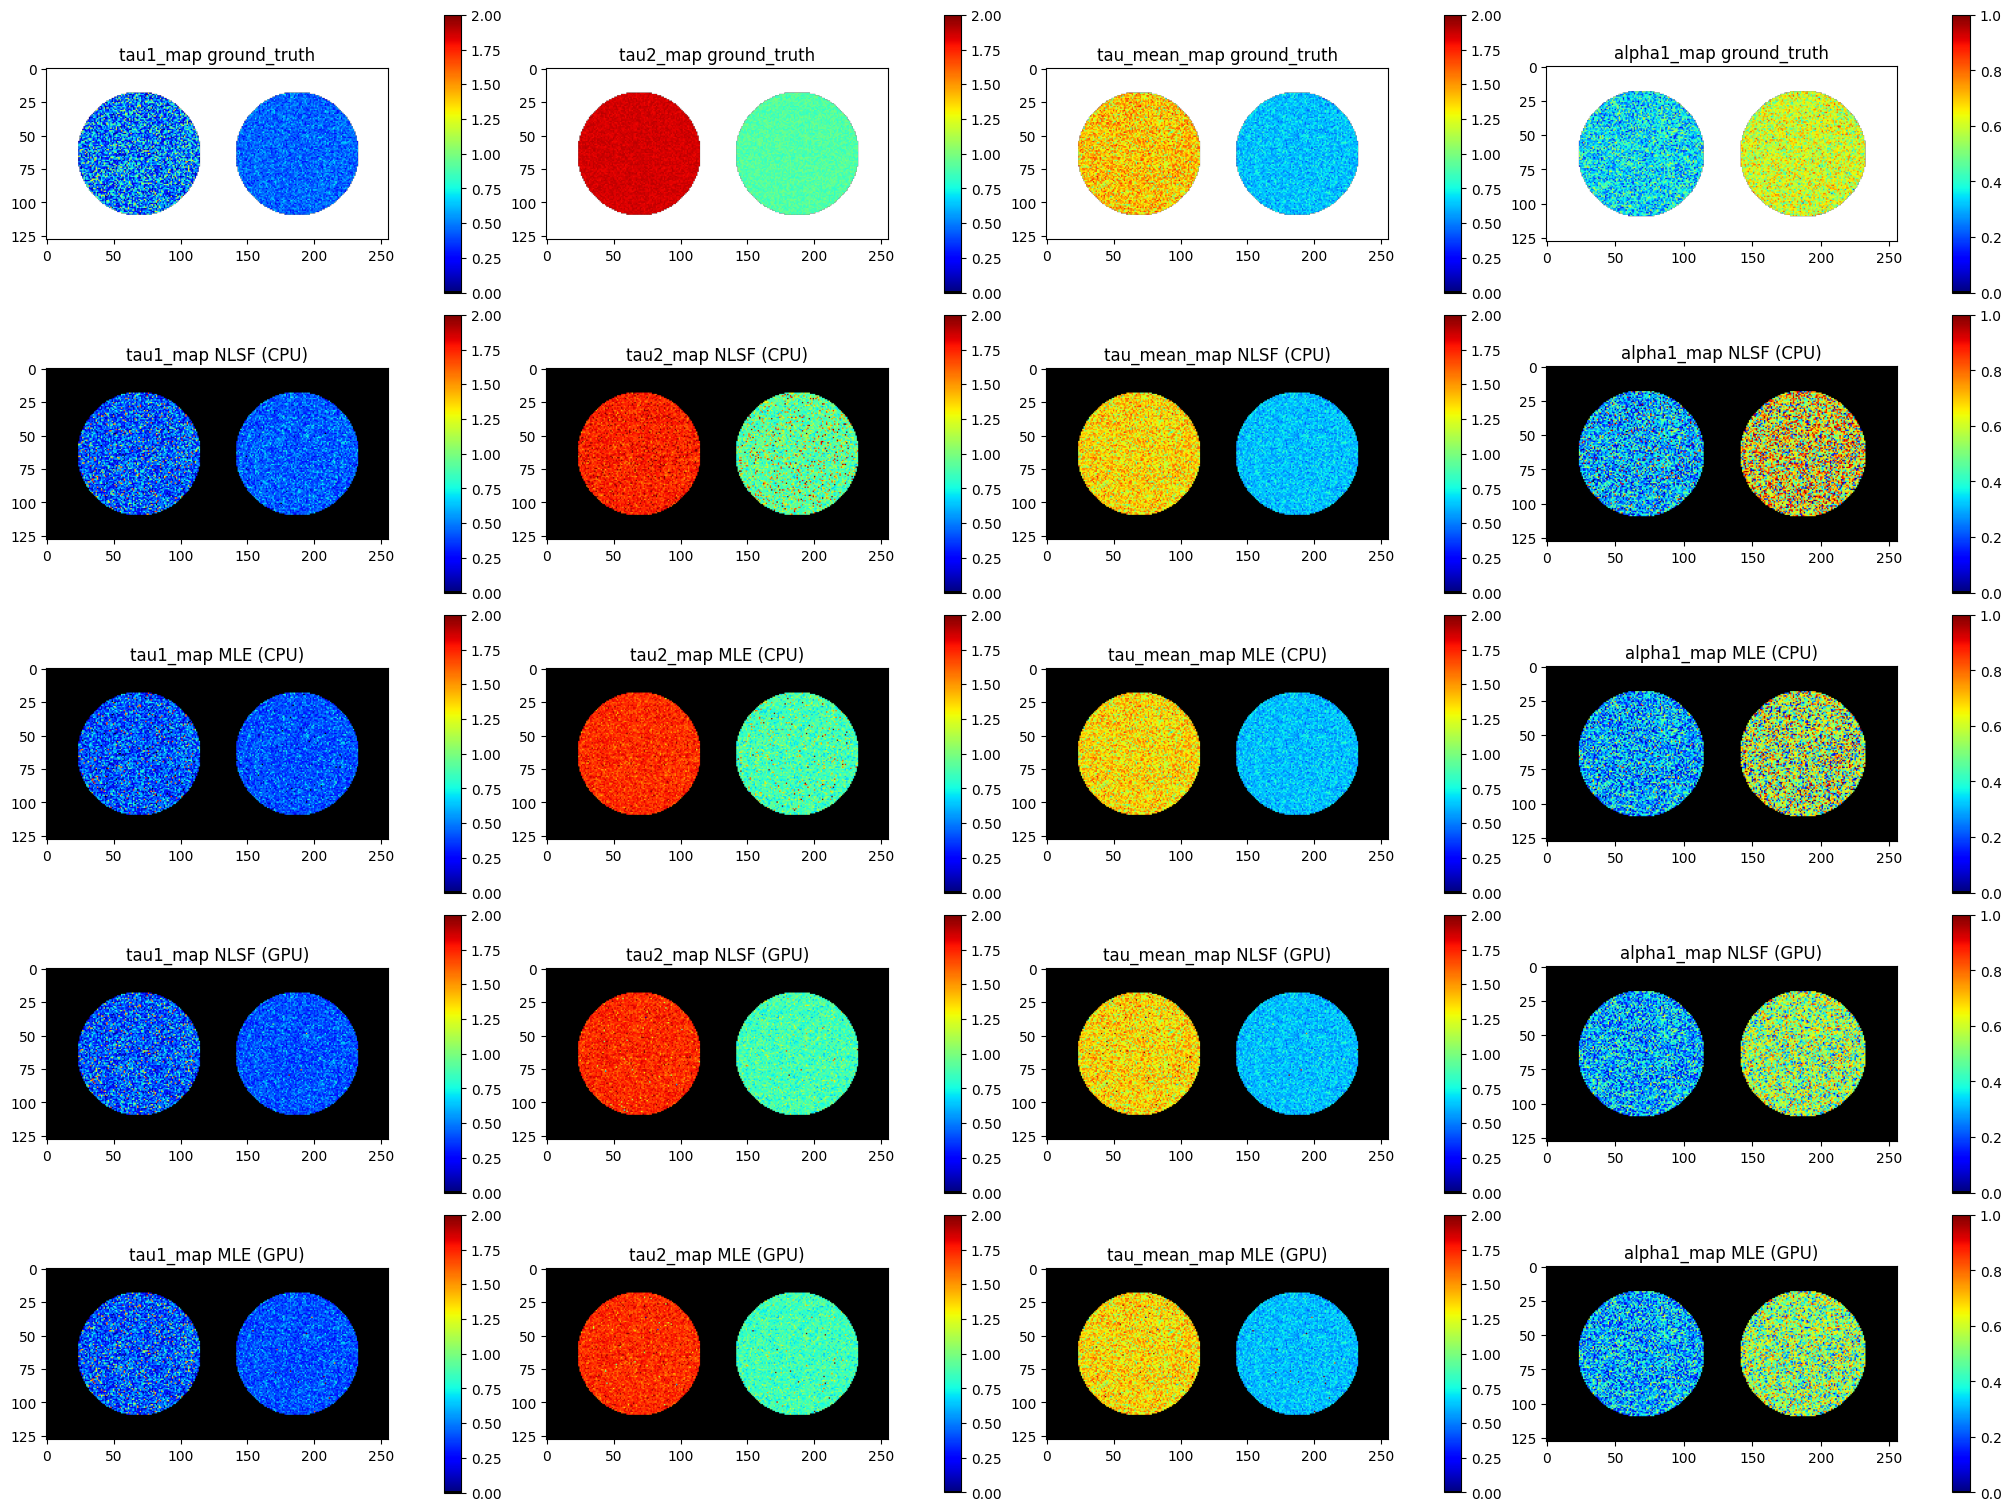

In [18]:
experiments_all = {
    "NLSF (CPU)": results_nlsf,
    "MLE (CPU)": results_mle,
    "NLSF (GPU)": results_gpu_nlsf,
    "MLE (GPU)": results_gpu_mle,
}
maps_all = [res["results"]["maps"] for res in experiments_all.values()]
fitsets_all = [res["results"]["TR_maps"] for res in experiments_all.values()]

keys_to_plot = ["tau1_map", "tau2_map", "tau_mean_map", "alpha1_map"]
sources = {"ground_truth": res_well, **dict(zip(experiments_all, maps_all))}

_ = DataViewer().display_data(
    [maps[key] for maps in sources.values() for key in keys_to_plot],
    structure=(len(sources), len(keys_to_plot)),
    coord=None,
    data_names=[f"{key} {name}" for name in sources for key in keys_to_plot],
    cmaps=[jet_m_well] * len(sources) * len(keys_to_plot),
    v_ranges=[(0, 2), (0, 2), (0, 2), (0, 1)] * len(sources),
    figsize=(20, 15),
    normalize=False,
    yscale="linear",
)

### Parameter distributions

`Plotter` compares the parameter values of the well pixels across the sources. The `operations` dict is applied to every source: it keeps only pixels inside the mask, drops failed fits (NaN or zero) and discards values outside the threshold range. A list of dicts, one per source, can be passed instead to filter each source differently. `graph_type` can also be `"box"`, `"swarm"`, `"overlay"`, `"raincloud"` or `"kde"`, and `test_type="paired"` or `"welch"` adds significance tests between the sources.

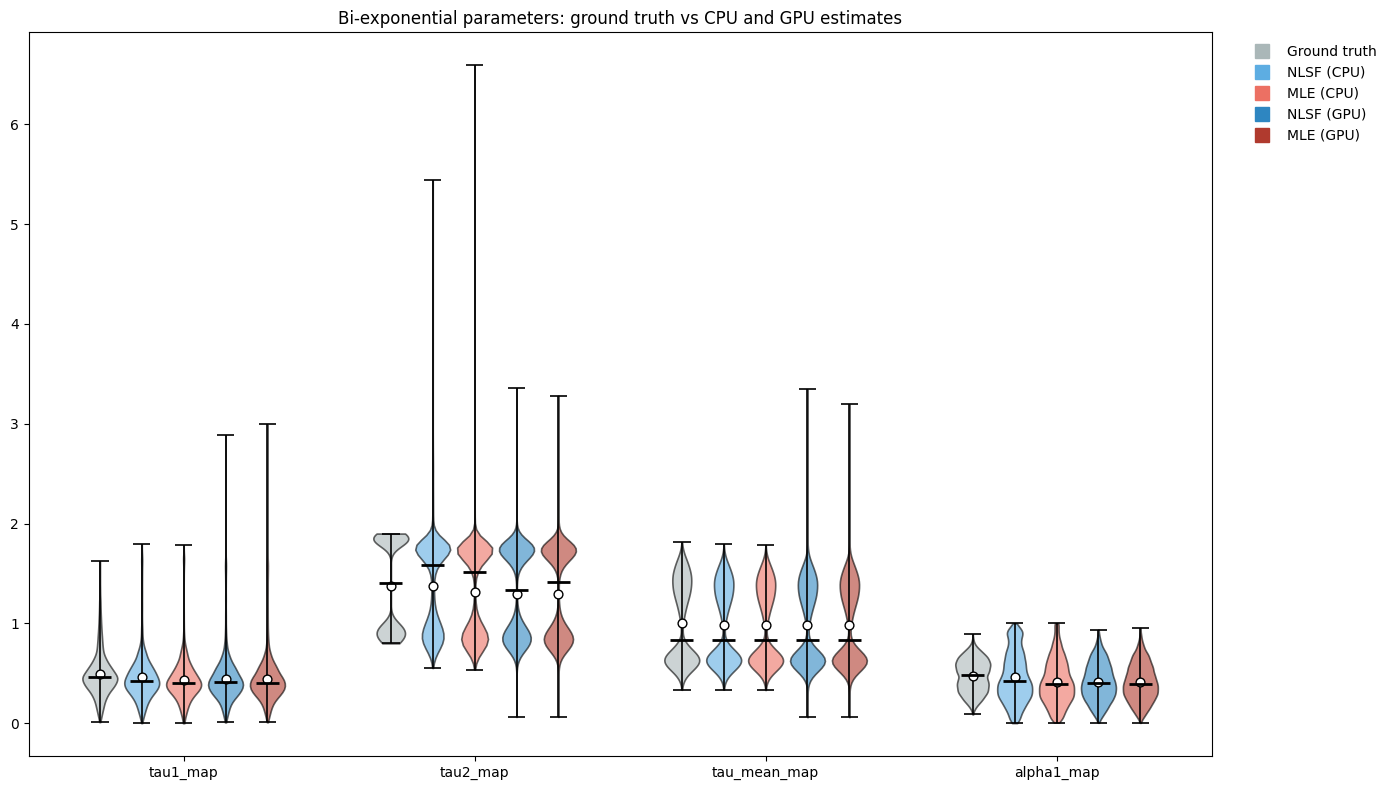

In [19]:
plotter_ops = {
    "mask": b_bool_mask_well.ravel(),
    "remove_nan": True,
    "remove_zero": True,
    "threshold": (0, 7),
}

painter_all = Plotter(
    res_well,
    *maps_all,
    values=keys_to_plot,
    style_config=["#AAB7B8", "#5DADE2", "#EC7063", "#2E86C1", "#B03A2E"],
    source_names=["Ground truth"] + list(experiments_all),
    operations=plotter_ops,
)
fig = painter_all.make_plot(
    title="Bi-exponential parameters: ground truth vs CPU and GPU estimates",
    graph_type="violin",
    point_type="strip",
    show_mean=True,
    show_median=True,
    show_significance=True,
    test_type="none",
    correction=False,
)

### Accuracy and fit quality

Per method, over the well pixels: the median relative bias and the spread of `estimate / truth - 1` for `tau_mean`, `tau1` and `tau2`, the median absolute error of `alpha1`, the median reduced chi-square (Poisson deviance over its expectation, about 1 for a good fit), and the number of pixels without a valid estimate. The CPU fitting times are shown by the progress bars of the CPU cells above.

In [28]:
wells = b_bool_mask_well.astype(bool)
fit_times = {"NLSF (GPU)": time_gpu_nlsf, "MLE (GPU)": time_gpu_mle}

rows = []
for name, maps in zip(experiments_all, maps_all):
    valid = np.isfinite(maps["tau_mean_map"][wells]) & (maps["tau_mean_map"][wells] > 0)
    row = {"method": name}
    for key in ["tau_mean_map", "tau1_map", "tau2_map"]:
        rel = maps[key][wells][valid] / res_well[key][wells][valid] - 1.0
        label = key.replace("_map", "")
        row[f"{label} bias (%)"] = 100 * np.median(rel)
        row[f"{label} spread (%)"] = 100 * np.std(rel)
    row["alpha1 |error|"] = np.median(np.abs(maps["alpha1_map"][wells][valid] - res_well["alpha1_map"][wells][valid]))
    row["median reduced chi2"] = np.nanmedian(maps["reduced_chi2_map"][wells][valid])
    rows.append(row)
pd.DataFrame(rows).set_index("method").round(3)

,tau_mean bias (%),tau_mean spread (%),tau1 bias (%),tau1 spread (%),tau2 bias (%),tau2 spread (%),alpha1 |error|,median reduced chi2
method,,,,,,,,
NLSF (CPU),-1.557,2.201,-3.770,22.771,-4.009,24.036,0.066,1.031
MLE (CPU),-1.942,2.095,-6.491,18.982,-5.795,22.746,0.063,1.014
NLSF (GPU),-1.970,7.249,-8.026,27.560,-5.657,10.050,0.063,1.056
MLE (GPU),-2.167,8.804,-8.511,25.148,-6.145,10.597,0.064,1.048


### CPU vs GPU, pixel by pixel

Each point is one well pixel: the GPU estimate against the CPU estimate for the same estimator, for the mean lifetime `tau_mean` and the fraction `alpha1`. Points on the diagonal mean both processors reached the same solution.

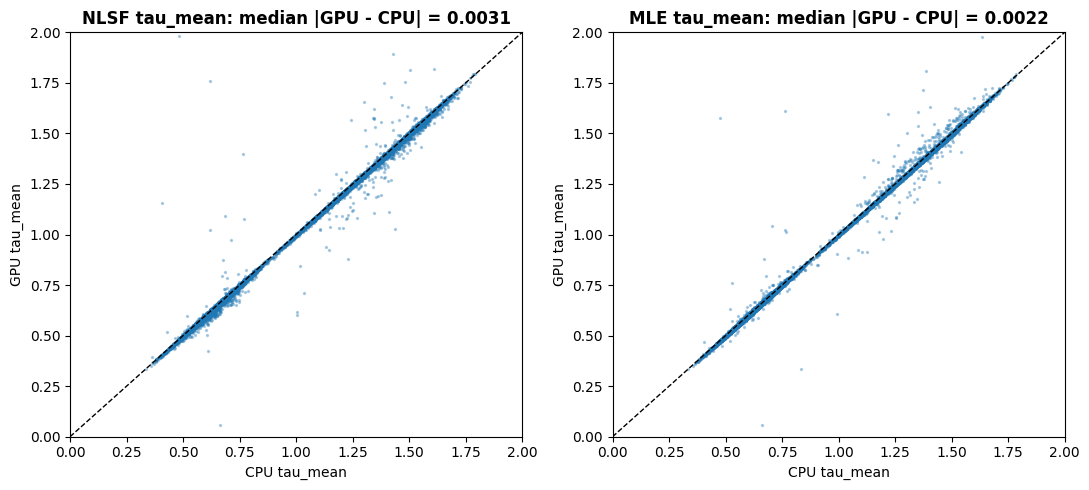

In [27]:
plots = [("tau_mean_map", (0, 2))]
estimators = ["NLSF", "MLE"]
fig, axes = plt.subplots(
    len(plots), len(estimators), figsize=(11, 5 * len(plots)), squeeze=False
)
for row, (key, lim) in enumerate(plots):
    for col, est in enumerate(estimators):
        ax = axes[row, col]
        cpu = experiments_all[f"{est} (CPU)"]["results"]["maps"][key][wells]
        gpu = experiments_all[f"{est} (GPU)"]["results"]["maps"][key][wells]
        ok = np.isfinite(cpu) & np.isfinite(gpu)
        ax.scatter(cpu[ok], gpu[ok], s=2, alpha=0.3)
        ax.plot(lim, lim, "k--", linewidth=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        label = key.replace("_map", "")
        ax.set_title(f"{est} {label}: median |GPU - CPU| = {np.median(np.abs(gpu[ok] - cpu[ok])):.4f}", fontweight="bold")
        ax.set_xlabel(f"CPU {label}")
        ax.set_ylabel(f"GPU {label}")
fig.tight_layout()
plt.show()


### Fits at a single pixel

The pixel probed in the ground-truth check above, now with all four fitted curves.

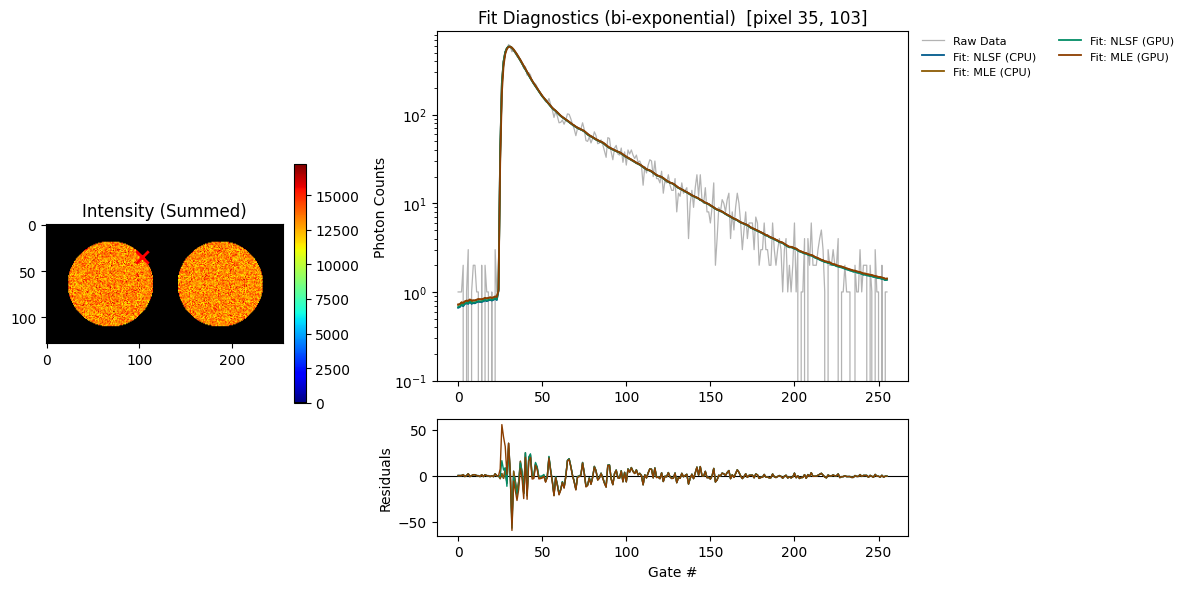

In [22]:
_ = plot_pixel_diagnostic(
    _decay_well,
    fitsets_all,
    list(experiments_all),
    mask=b_bool_mask_well,
    pixel=(x_well, y_well),
    t=None,
    yscale="log",
    raw_style="line",
    model_type=MODEL_TYPE,
)

- The GPU processor uses the same model and estimators as the CPU fitters but fits the whole image as one batch. Whether it is faster depends on the image size, the number of Adam steps (`max_iter`) and the hardware -- compare the fit times above with the CPU progress bars.
- The CPU fitters optimize every pixel to convergence, while the GPU runs one Adam step budget for all pixels together. Pixels that converge slowly -- common in bi-exponential fits, where `alpha1`, `tau1` and `tau2` trade off against each other -- can end up further from the optimum on the GPU, which shows as a wider spread in the table and as points off the diagonal above; a larger `max_iter` reduces it.

## Phasor computation and visualization

In [23]:
time_axis_ns_well = np.linspace(0, gate_delay * num_gates, _irf_well.shape[2])
phasor_well = PhasorAnalyzer(
    frequency_hz=freq_hz, time_axis_ns=time_axis_ns_well, n_harmonics=3
)
G_well, S_well = phasor_well.create_phasor_gpu(_decay_well)
Gc_well, Sc_well = phasor_well.calibrate_pixelwise(G_well, S_well, _irf_well)
tau_map_ns_well = phasor_well.compute_lifetime(Gc_well[0], Sc_well[0])

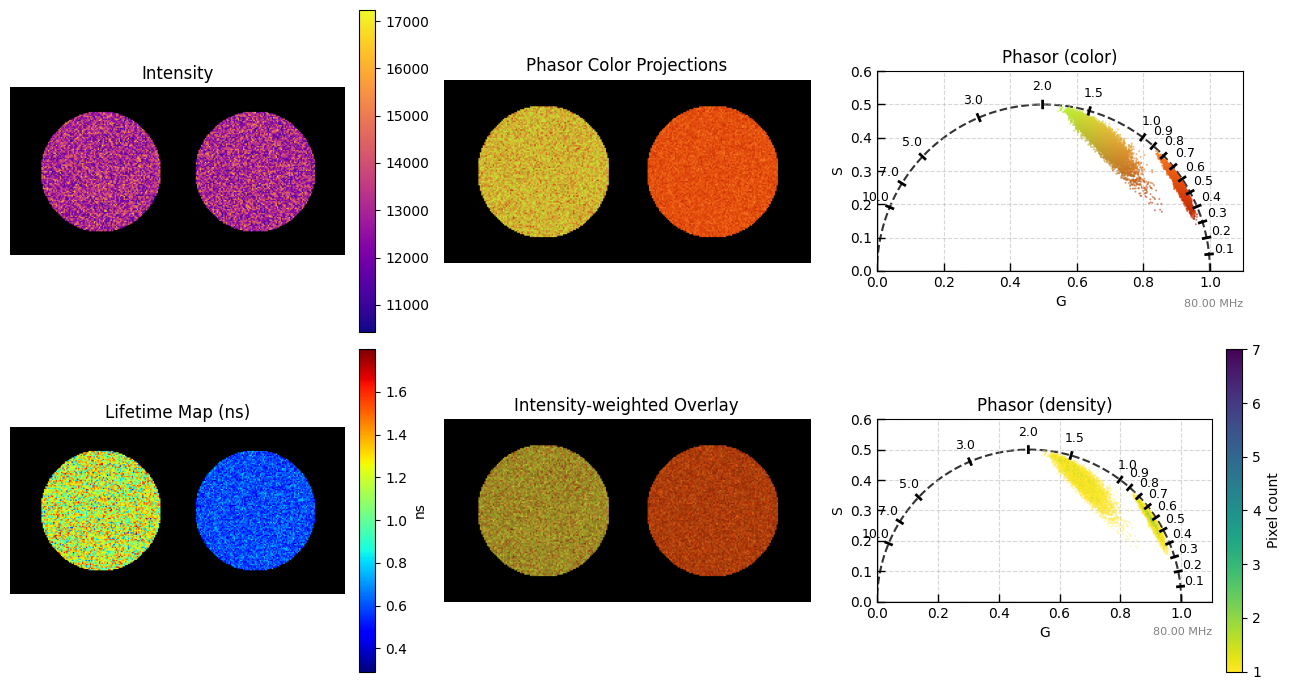

In [24]:
im2_well = phasor_well.plot_overlay_subplots(
    _decay_well,
    Gc_well[0],
    Sc_well[0],
    mask=b_bool_mask_well,
    colormaps=["plasma", "jet", "turbo_r", ph_cols_],
    figsize=(13, 7),
    xlim=(0, 1.1),
    bg_color=bg_color,
    transpose=False,
    kdeplot=False,
)